In [148]:
from __future__ import annotations

import pathlib

import os
import yaml
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.axes import Axes
from pete import pset

pset.setup(fig_dir="figures")


In [149]:
def align_yaxis_to_zero(ax1: Axes, ax2: Axes) -> None:
    """Align y=0 of two twinx axes."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    frac1 = abs(y1_min) / (abs(y1_min) + abs(y1_max))
    frac2 = abs(y2_min) / (abs(y2_min) + abs(y2_max))

    if frac1 < frac2:
        new_min = -frac2 * y1_max / (1 - frac2)
        ax1.set_ylim(new_min, y1_max)
    else:
        new_min = -frac1 * y2_max / (1 - frac1)
        ax2.set_ylim(new_min, y2_max)

## SHiP magnet dataset

In [150]:
DATA_DIR = pathlib.Path("data")
FNAME = "Results_S356_SHiP"

sheets = pd.read_excel(DATA_DIR / f"{FNAME}.xlsx", sheet_name=None)
sheets.keys()

dict_keys(['Initial_magnetization_curve', 'Major_hysteresis_loop', 'Statistics'])

Major hysteresis loops

In [151]:
sheets["Major_hysteresis_loop"]

,S356,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35
0,Plate 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MPE,NaN,NaN,NaN,NaN,NaN,MPM,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,MPM,NaN,NaN,NaN,NaN,NaN
2,1A - Top,NaN,1B - Center,NaN,1C - Bottom,NaN,4A - Top,NaN,4B - Center,NaN,...,9B - Center,NaN,9C - Bottom,NaN,12A - Top,NaN,12B - Center,NaN,12C - Bottom,NaN
3,H (A/m),B(T),H (A/m),B(T),H (A/m),B(T),H (A/m),B(T),H (A/m),B(T),...,H (A/m),B(T),H (A/m),B(T),H (A/m),B(T),H (A/m),B(T),H (A/m),B(T)
4,19335.7,1.968785,19330.8,1.94568,19328,1.955858,19331.7,1.957762,19331.5,1.9598,...,19335.3,1.952708,Not cut,NaN,Not cut,NaN,19347.9,1.95755,Not cut,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242,Max measured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,NaN,1A,1B,1C,4A,4B,4C,NaN,NaN,NaN,...,9B,9C,12A,12B,12C,NaN,NaN,NaN,NaN,NaN
244,Hc (A/m),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
def extract_hb_datasets(
    df: pd.DataFrame,
    *,
    skip_rows: int = 4,
    stop_row: int | None = None,
    skip_cols_1based: list[int] | None = None,
    max_col: int | None = None,
) -> list[pd.DataFrame]:
    """
    Return a list of DataFrames (columns ['H','B']) extracted from `df`.

    Uses the literal default skip list `DEFAULT_SKIP_COLS` when `skip_cols_1based` is None.
    - skip_rows: top rows to skip (default 4)
    - skip_cols_1based: 1-based column indices to skip (override default if provided)
    - max_col: limit to first max_col columns; if None use all columns
    """
    df2 = df.iloc[skip_rows:stop_row].reset_index(drop=True)
    n_available = len(df2.columns) if max_col is None else min(max_col, len(df2.columns))
    cols = list(df2.columns[:n_available])

    skip_cols_1based = skip_cols_1based or []

    skip0 = {i - 1 for i in skip_cols_1based if 1 <= i <= len(cols)}  # convert to 0-based, ignore OOB
    kept_cols = [c for i, c in enumerate(cols) if i not in skip0]
    df_kept = df2.loc[:, kept_cols].apply(pd.to_numeric, errors="coerce")

    if df_kept.shape[1] % 2 != 0:
        msg = f"Kept columns count ({df_kept.shape[1]}) is not even; cannot form H,B pairs"
        raise ValueError(msg)

    n_pairs = df_kept.shape[1] // 2
    return [
        pd.DataFrame(
            {
                "H": df_kept.iloc[:, 2 * i].reset_index(drop=True),
                "B": df_kept.iloc[:, 2 * i + 1].reset_index(drop=True),
            }
        )
        for i in range(n_pairs)
    ]

In [153]:
# columns to skip (1-based indices)
skip_cols_1based = [13, 14, 17, 18, 19, 20, 23, 24, 25, 26, 29, 30, 31, 32, 35, 36]

datasets = extract_hb_datasets(
    sheets["Major_hysteresis_loop"],
    skip_rows=4,
    skip_cols_1based=skip_cols_1based,
    stop_row=242
    )

In [154]:
datasets[0].max()

H    19340.100000
B        1.968905
dtype: float64

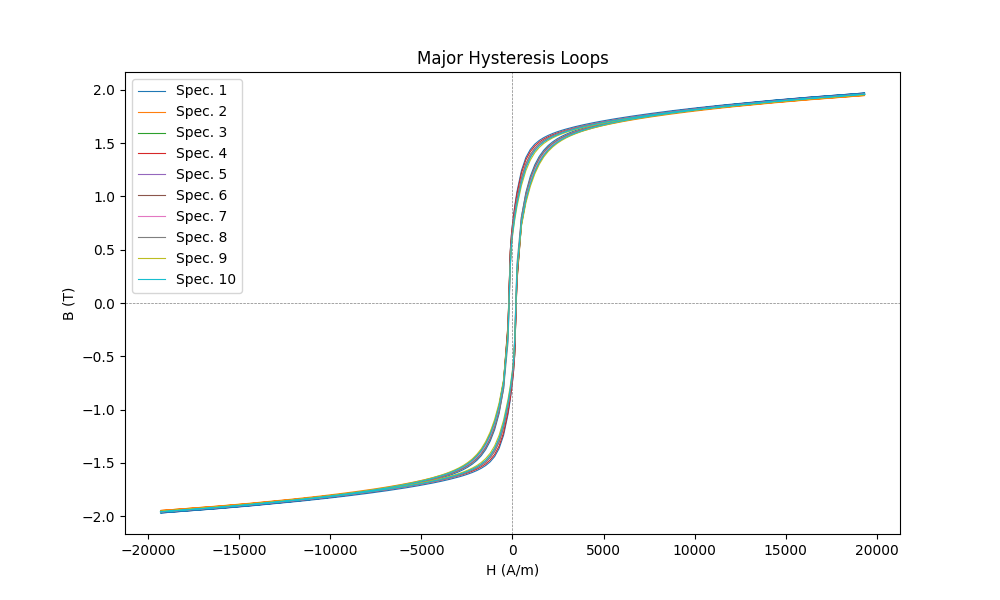

In [155]:
with pset.subplots(name="major_hyst_loops", figsize=(10, 6)) as (fig, ax):

    for i, df in enumerate(datasets):
        ax.plot(df["H"], df["B"], label=f"Spec. {i + 1}", linewidth=0.8)
    ax.set_xlabel("H (A/m)")
    ax.set_ylabel("B (T)")
    ax.set_title("Major Hysteresis Loops")

    ax.axvline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.legend()

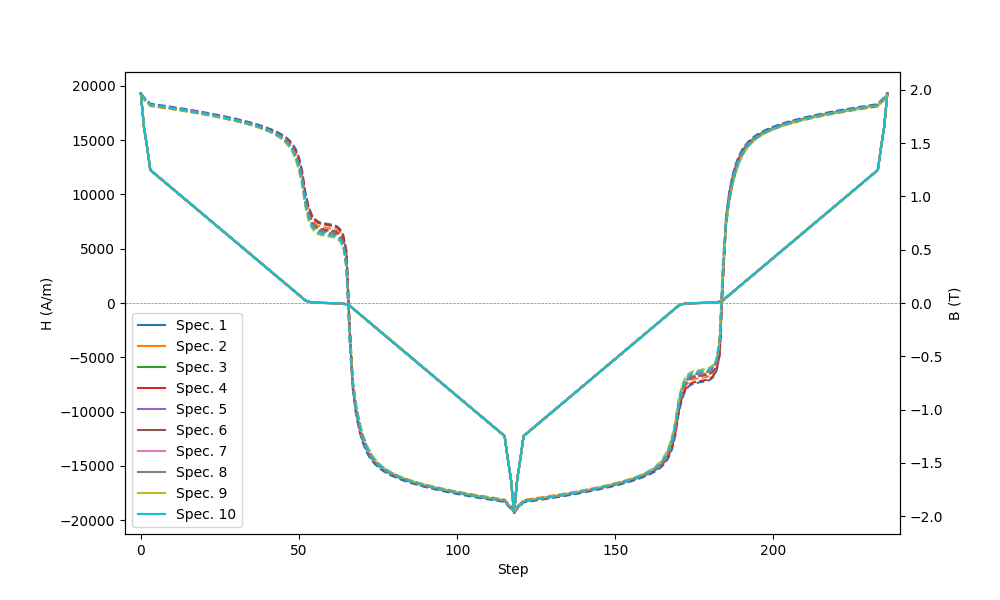

In [156]:
with pset.subplots(name="major_hyst_loops_timeseries", figsize=(10, 6)) as (fig, ax):

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)

    ax2 = ax.twinx()
    for i, df in enumerate(datasets):
        ax.plot(df["H"], label=f"Spec. {i + 1}")
        ax2.plot(df["B"], label=f"Spec. {i + 1}", linestyle="--")
    ax.set_xlabel("Step")
    ax.set_ylabel("H (A/m)")
    ax2.set_ylabel("B (T)")
    # ax.set_title("Major Hysteresis Loops")
    # ax.grid()
    align_yaxis_to_zero(ax, ax2)
    ax.set_xlim(-5, 240)
    ax.legend()

In [157]:
maj_hyst_datasets = datasets
MAJ_HYST_DIR = DATA_DIR / "SHiP" / "major_hyst_loop"
MAJ_HYST_DIR.mkdir(parents=True, exist_ok=True)
maj_hyst_paths = [MAJ_HYST_DIR / f"spec_{i + 1}.parquet" for i in range(len(datasets))]

for i, (dataset, path) in enumerate(zip(maj_hyst_datasets, maj_hyst_paths, strict=True)):
    dataset.to_parquet(path)

Initial magnetization curves

In [158]:
sheets["Initial_magnetization_curve"]

,S356,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,Plate 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MPM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AVERAGE,NaN,NaN
2,1A-Top,NaN,NaN,1B-Middle,NaN,NaN,1C-Bottom,NaN,NaN,4A-Top,...,NaN,4C-Bottom,NaN,NaN,NaN,NaN,NaN,H (A/m),B(T),μr (-)
3,H (A/m),B(T),μr (-),H (A/m),B(T),μr (-),H (A/m),B(T),μr (-),H (A/m),...,μr (-),H (A/m),B(T),μr (-),NaN,NaN,NaN,NaN,NaN,NaN
4,4.12507,0.001258,242.598,4.12194,0.001309,252.736,4.1232,0.001357,261.87,4.12182,...,271.803,4.13065,0.001273,245.341,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,NaN,NaN,NaN,5950.83,1.70403,227.871,NaN,NaN,NaN,NaN,...,228.393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,NaN,NaN,NaN,8418.4,1.77365,167.66,NaN,NaN,NaN,NaN,...,167.993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,NaN,NaN,NaN,10875.2,1.82661,133.659,NaN,NaN,NaN,NaN,...,133.925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,NaN,NaN,NaN,15794.3,1.9101,96.2383,NaN,NaN,NaN,NaN,...,96.4202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
initial_mag_datasets = extract_hb_datasets(
    sheets["Initial_magnetization_curve"],
    skip_rows=4,
    skip_cols_1based=[3, 6, 9, 12, 15, 18],
    stop_row=41,
    max_col=18
)

initial_mag_datasets += extract_hb_datasets(
    sheets["Initial_magnetization_curve"],
    skip_rows=46,
    skip_cols_1based=[1, 4, 5, 6, 9, 10],
    stop_row=82,
    max_col=10
)

initial_mag_datasets += extract_hb_datasets(
    sheets["Initial_magnetization_curve"],
    skip_rows=87,
    skip_cols_1based=[1, 4, 5, 6, 9, 10],
    stop_row=122,
    max_col=10
)

len(initial_mag_datasets)

10

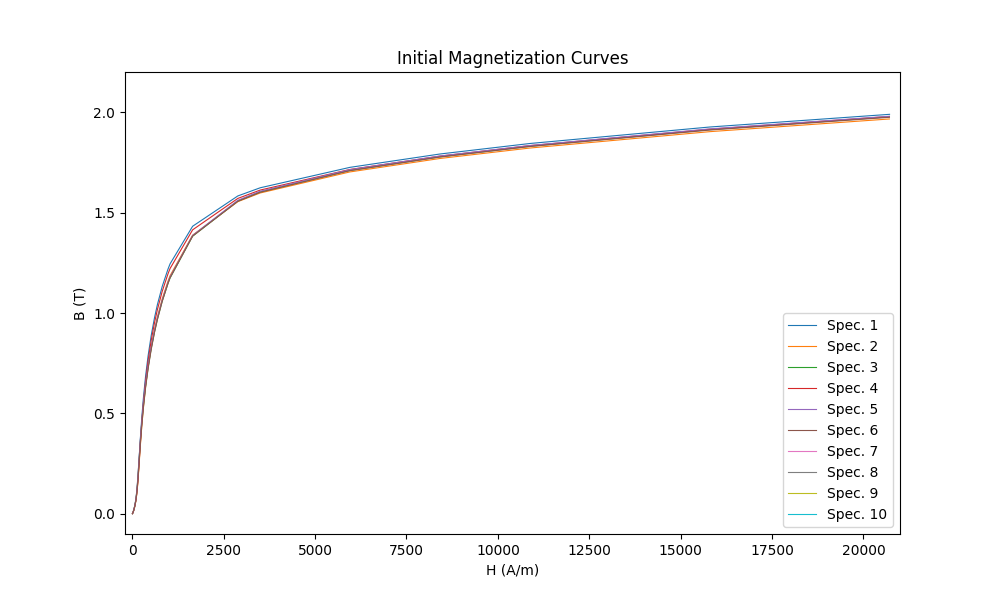

In [160]:
with pset.subplots(name="init_mag_curves", figsize=(10, 6)) as (fig, ax):

    for i, df in enumerate(initial_mag_datasets):
        ax.plot(df["H"], df["B"], label=f"Spec. {i + 1}", linewidth=0.8)
    ax.set_xlabel("H (A/m)")
    ax.set_ylabel("B (T)")
    ax.set_title("Initial Magnetization Curves")
    ax.legend()
    ax.set_xlim(-200, 21000)
    ax.set_ylim(-0.1, 2.2)

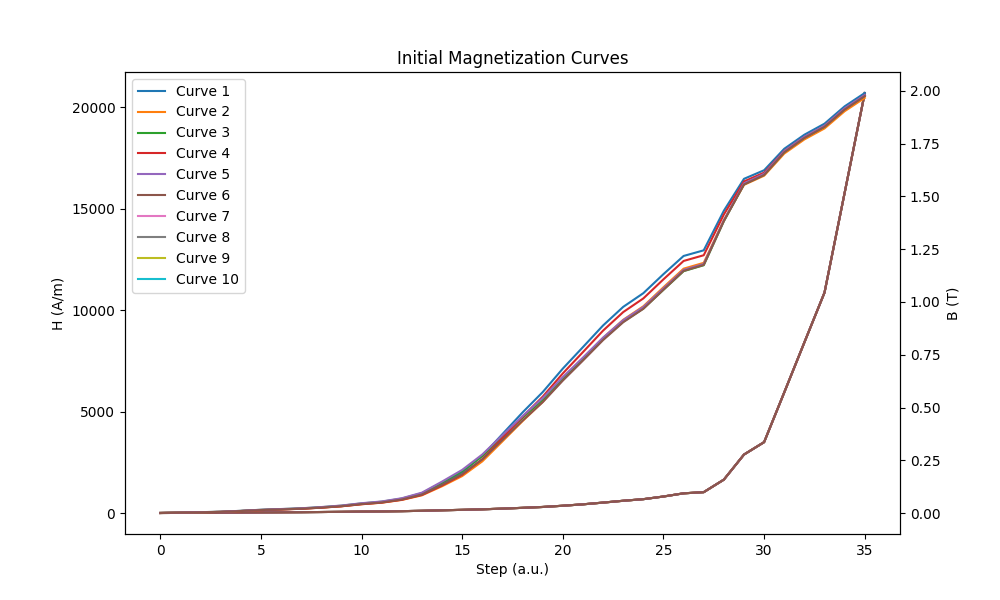

In [161]:
with pset.subplots(name="init_mag_curves", figsize=(10, 6)) as (fig, ax):

    ax2 = ax.twinx()
    for i, df in enumerate(initial_mag_datasets):
        ax.plot(df["H"], label=f"Curve {i + 1}")
        ax2.plot(df["B"], label=f"Curve {i + 1}")
    ax.set_xlabel("Step (a.u.)")
    ax.set_ylabel("H (A/m)")
    ax2.set_ylabel("B (T)")
    ax.set_title("Initial Magnetization Curves")
    ax.legend()

In [162]:
INITIAL_MAG_DIR = DATA_DIR / "SHiP" / "initial_mag"
INITIAL_MAG_DIR.mkdir(parents=True, exist_ok=True)
initial_mag_paths = [INITIAL_MAG_DIR / f"spec_{i + 1}.parquet" for i in range(len(datasets))]

for i, (dataset, path) in enumerate(zip(initial_mag_datasets, initial_mag_paths, strict=True)):
    dataset.to_parquet(path)

## GSI ARMCO dataset

In [163]:
sheets_gsi = pd.read_excel(DATA_DIR / "Results_GSI_ARMCO.xlsx", sheet_name=None)
sheets_gsi.keys()

dict_keys(['Initial_magnetization_curve', 'Major_hysteresis_loop', 'Minor_loops', 'Summary'])

In [164]:
gsi_major_hyst_datasets = extract_hb_datasets(
    sheets_gsi["Major_hysteresis_loop"],
    skip_rows=2,
    skip_cols_1based=[],
    stop_row=240,
    max_col=8,
)

gsi_initial_mag_datasets = extract_hb_datasets(
    sheets_gsi["Initial_magnetization_curve"],
    skip_rows=2,
    skip_cols_1based=list(range(3, 13, 3)),
    stop_row=39,
    max_col=13,
)

gsi_minor_hyst_datasets = extract_hb_datasets(
    sheets_gsi["Minor_loops"],
    skip_rows=2,
    skip_cols_1based=[],
    stop_row=258,
)


len(gsi_major_hyst_datasets), len(gsi_initial_mag_datasets), len(gsi_minor_hyst_datasets)

(4, 4, 4)

In [165]:
list(range(4, 14, 3))

[4, 7, 10, 13]

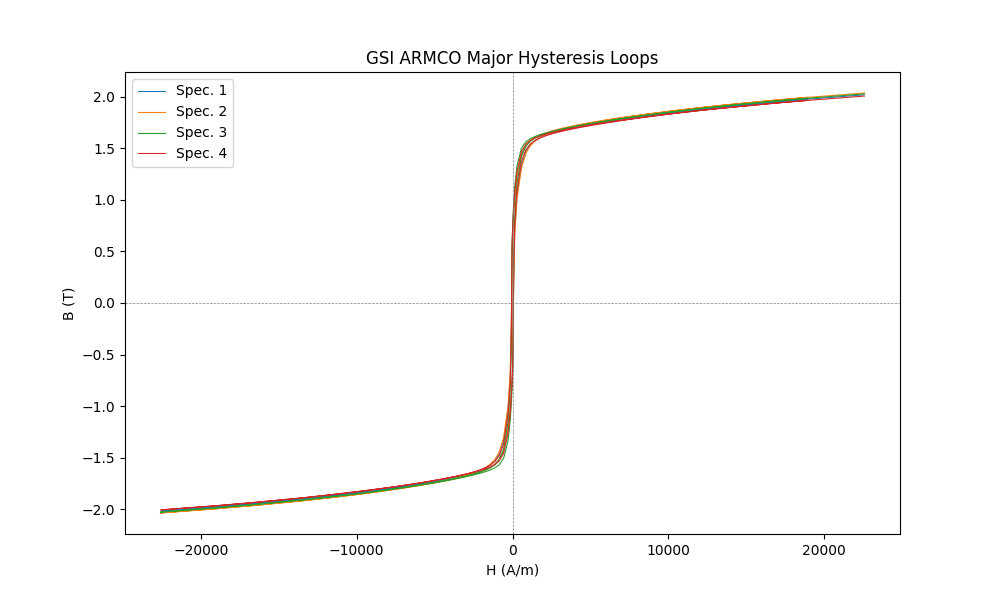

In [166]:
with pset.subplots(name="gsi_major_hyst_loops", figsize=(10, 6)) as (fig, ax):

    for i, df in enumerate(gsi_major_hyst_datasets):
        ax.plot(df["H"], df["B"], label=f"Spec. {i + 1}", linewidth=0.8)
    ax.set_xlabel("H (A/m)")
    ax.set_ylabel("B (T)")
    ax.set_title("GSI ARMCO Major Hysteresis Loops")

    ax.axvline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.legend()

In [167]:
gsi_major_hyst_datasets[0][-10:]

,H,B
226,12585.0,1.8865
227,12871.0,1.8911
228,13157.0,1.8957
229,13443.0,1.9002
230,13729.0,1.9047
231,14015.0,1.9091
232,14301.0,1.9134
233,16739.0,1.9482
234,18922.0,1.9765
235,22557.0,2.0183


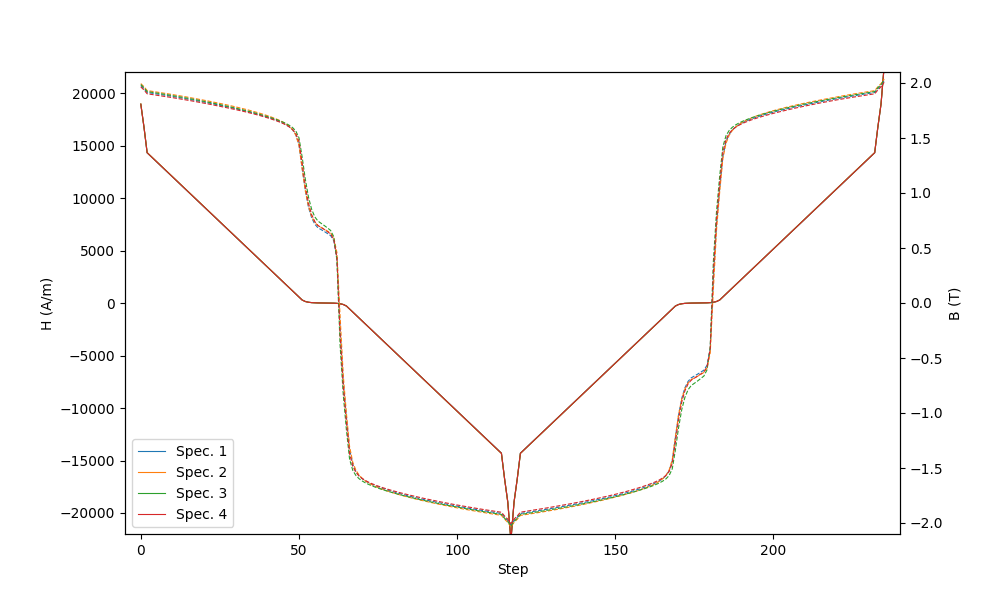

In [168]:
with pset.subplots(name="gsi_major_hyst_loops_timeseries", figsize=(10, 6)) as (fig, ax):

    ax2 = ax.twinx()
    for i, df in enumerate(gsi_major_hyst_datasets):
        ax.plot(df["H"], label=f"Spec. {i + 1}", linewidth=0.8)
        ax2.plot(df["B"], label=f"Spec. {i + 1}", linestyle="--", linewidth=0.8)

    ax.set_xlabel("Step")
    ax.set_ylabel("H (A/m)")
    ax2.set_ylabel("B (T)")
    ax.set_xlim(-5, 240)
    ax.set_ylim(-22000, 22000)
    ax2.set_ylim(-2.1, 2.1)

    ax.legend()

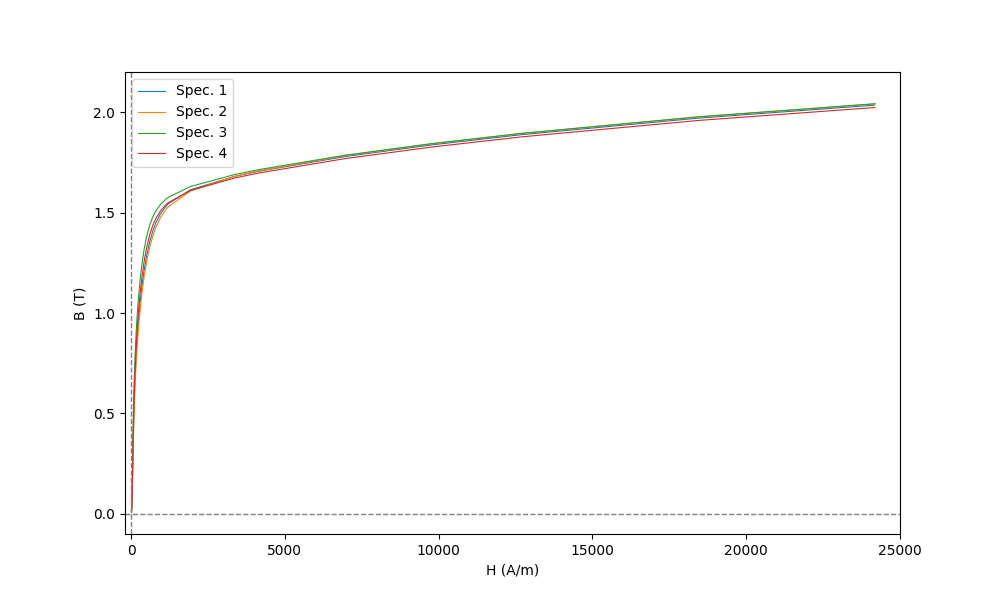

In [169]:
with pset.subplots(name="gsi_initial_mag_curves", figsize=(10, 6)) as (fig, ax):

    for i, df in enumerate(gsi_initial_mag_datasets):
        ax.plot(df["H"], df["B"], label=f"Spec. {i + 1}", linewidth=0.8)
    ax.set_xlabel("H (A/m)")
    ax.set_ylabel("B (T)")
    # ax.set_title("GSI ARMCO Initial Magnetization Curves")
    ax.legend()
    ax.set_xlim(-200, 25000)
    ax.set_ylim(-0.1, 2.2)

    ax.axvline(0, color="gray", linestyle="--", linewidth=1.0)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1.0)

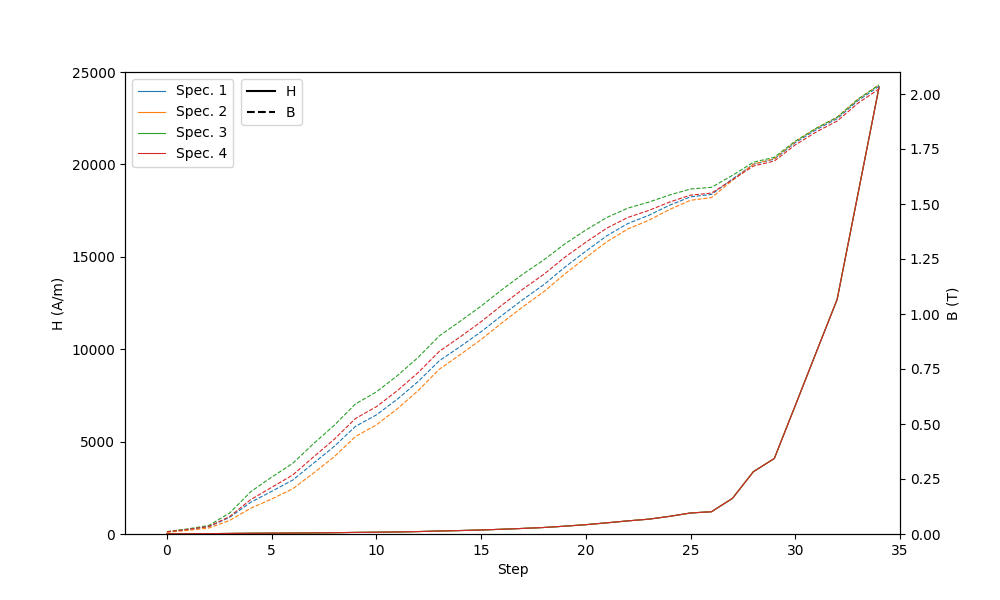

In [170]:
with pset.subplots(name="gsi_major_hyst_loops_timeseries", figsize=(10, 6)) as (fig, ax):
    ax2 = ax.twinx()
    for i, df in enumerate(gsi_initial_mag_datasets):
        ax.plot(df["H"], label=f"Spec. {i + 1}", linewidth=0.8)
        ax2.plot(df["B"], label=f"Spec. {i + 1}", linestyle="--", linewidth=0.8)

    ax.set_xlabel("Step")
    ax.set_ylabel("H (A/m)")
    ax2.set_ylabel("B (T)")
    ax.set_xlim(-2, 35)
    ax.set_ylim(0, 25000)
    ax2.set_ylim(0, 2.1)

    ax.legend()
    # annotate solid vs dashed in legend
    ax2.legend(handles=[
            plt.Line2D([], [], color="black", linestyle="-", label="H"),
            plt.Line2D([], [], color="black", linestyle="--", label="B"),
        ],
        loc=(0.15, 0.885)
    )

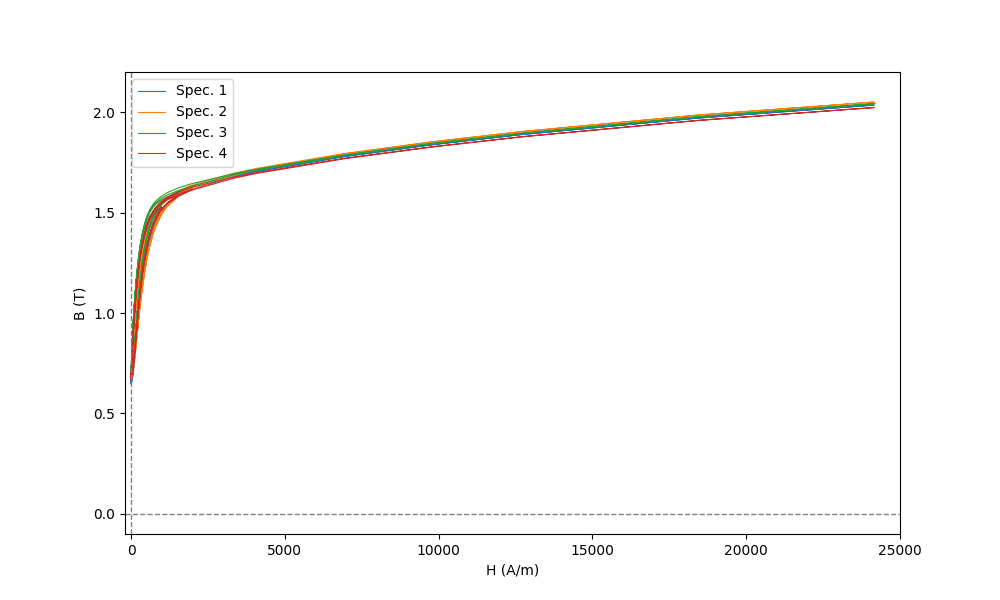

In [171]:
with pset.subplots(name="gsi_minor_hyst_loops", figsize=(10, 6)) as (fig, ax):
    for i, df in enumerate(gsi_minor_hyst_datasets):
        ax.plot(df["H"], df["B"], label=f"Spec. {i + 1}", linewidth=0.8)
    ax.set_xlabel("H (A/m)")
    ax.set_ylabel("B (T)")
    # ax.set_title("GSI ARMCO Minor Hysteresis Loops")
    ax.legend()
    ax.set_xlim(-200, 25000)
    ax.set_ylim(-0.1, 2.2)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1.0)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1.0)

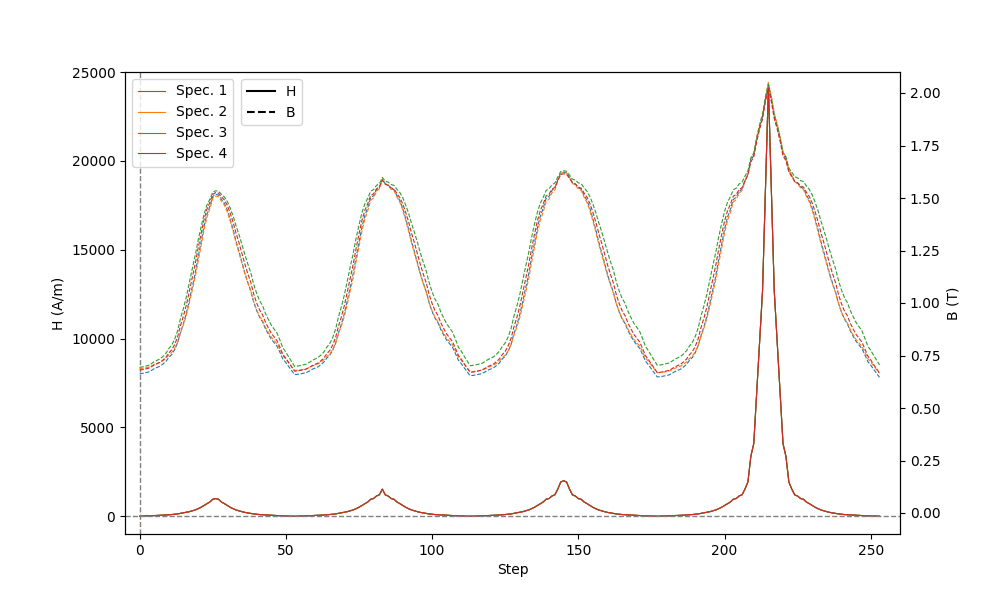

In [172]:
with pset.subplots(name="gsi_minor_hyst_loops_timeseries", figsize=(10, 6)) as (fig, ax):
    ax2 = ax.twinx()
    for i, df in enumerate(gsi_minor_hyst_datasets):
        ax.plot(df["H"], label=f"Spec. {i + 1}", linewidth=0.8)
        ax2.plot(df["B"], label=f"Spec. {i + 1}", linestyle="--", linewidth=0.8)

    ax.set_xlabel("Step")
    ax.set_ylabel("H (A/m)")
    ax2.set_ylabel("B (T)")
    ax.set_xlim(-5, 260)
    ax.set_ylim(-1000, 25000)
    ax2.set_ylim(-0.1, 2.1)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1.0)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1.0)

    ax.legend(loc="upper left")
    ax2.legend(handles=[
            plt.Line2D([], [], color="black", linestyle="-", label="H"),
            plt.Line2D([], [], color="black", linestyle="--", label="B"),
        ],
        loc=(0.15, 0.885)
    )

In [173]:
GSI_ARMCO_DIR = DATA_DIR / "GSI_ARMCO"
GSI_ARMCO_DIR.mkdir(parents=True, exist_ok=True)

GSI_MAJ_HYST_DIR = GSI_ARMCO_DIR / "major_hyst_loop"
GSI_MAJ_HYST_DIR.mkdir(parents=True, exist_ok=True)
gsi_maj_hyst_paths = [GSI_MAJ_HYST_DIR / f"spec_{i + 1}.parquet" for i in range(len(gsi_major_hyst_datasets))]

for i, (dataset, path) in enumerate(zip(gsi_major_hyst_datasets, gsi_maj_hyst_paths, strict=True)):
    dataset.to_parquet(path)

GSI_INIT_MAG_DIR = GSI_ARMCO_DIR / "initial_mag"
GSI_INIT_MAG_DIR.mkdir(parents=True, exist_ok=True)
gsi_init_mag_paths = [GSI_INIT_MAG_DIR / f"spec_{i + 1}.parquet" for i in range(len(gsi_initial_mag_datasets))]

for i, (dataset, path) in enumerate(zip(gsi_initial_mag_datasets, gsi_init_mag_paths, strict=True)):
    dataset.to_parquet(path)

GSI_MINOR_HYST_DIR = GSI_ARMCO_DIR / "minor_hyst_loop"
GSI_MINOR_HYST_DIR.mkdir(parents=True, exist_ok=True)
gsi_minor_hyst_paths = [GSI_MINOR_HYST_DIR / f"spec_{i + 1}.parquet" for i in range(len(gsi_minor_hyst_datasets))]

for i, (dataset, path) in enumerate(zip(gsi_minor_hyst_datasets, gsi_minor_hyst_paths, strict=True)):
    dataset.to_parquet(path)

In [174]:
ship_manifest = {
    "major_hyst_loop": maj_hyst_paths,
    "initial_mag": initial_mag_paths,
}

with open(DATA_DIR / "ship_manifest.yaml", "w", encoding="utf-8") as f:
    yaml.dump(ship_manifest, f)

gsi_manifest = {
    "major_hyst_loop": gsi_maj_hyst_paths,
    "initial_mag": gsi_init_mag_paths,
    "minor_hyst_loop": gsi_minor_hyst_paths,
}

with open(DATA_DIR / "gsi_armco_manifest.yaml", "w", encoding="utf-8") as f:
    yaml.dump(gsi_manifest, f)